In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dsdata = xr.open_dataset("ds_CF_D.nc")
dsdata

<xarray.Dataset>
Dimensions:                          (lon: 24, lat: 16)
Coordinates:
  * lon                              (lon) float64 -158.8 -156.2 ... -101.2
  * lat                              (lat) float64 1.25 3.75 ... 36.25 38.75
Data variables: (12/58)
    allsc                            (lat, lon) float32 ...
    low                              (lat, lon) float32 ...
    allsc_std                        (lat, lon) float32 ...
    low_std                          (lat, lon) float32 ...
    D500                             (lat, lon) float32 ...
    RH500                            (lat, lon) float32 ...
    ...                               ...
    LWP                              (lat, lon) float64 ...
    q700                             (lat, lon) float64 ...
    Teff                             (lat, lon) float64 ...
    D500_era                         (lat, lon) float32 ...
    D500_std_era                     (lat, lon) float32 ...
    D                                (lat, lon) float64 ...

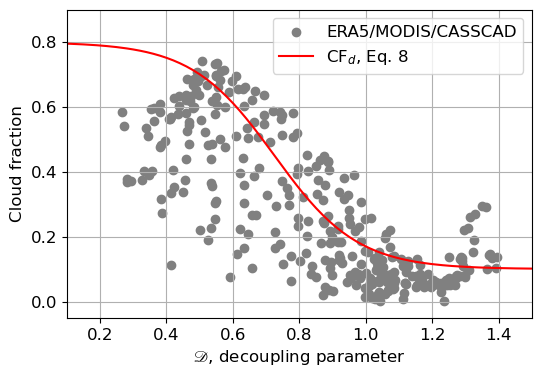

In [65]:
CFmax = 0.8
CFmin = 0.1
m = 8
dcrit = 1
def CFd(x): return CFmax - (CFmax - CFmin) / (1 + (1/9)*np.exp(-m*(x-dcrit)))

plt.rcParams.update({"font.size":12})
fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.scatter(dsdata.LHF / dsdata.dF * 0.4, dsdata.allsc, color="grey", label="ERA5/MODIS/CASSCAD")
x = np.linspace(0,10,1000)
ax.plot(x, CFd(x), "r-", label="CF$_{d}$, Eq. 8")
ax.set_xlim(0.1,1.5)
ax.set_ylim(-0.05,0.9)
ax.set_ylabel("Cloud fraction")
ax.set_xlabel("$\mathscr{D}$, decoupling parameter")
ax.legend()
ax.grid()
plt.rcParams.update({"font.size":12})

plt.savefig("D_vs_CF.pdf", facecolor="w", bbox_inches="tight", dpi=200)
plt.show()